In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('train.csv')
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
(df.isnull().sum() / len(df)) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df["Gender"].value_counts())
print(df["Married"].value_counts())
print(df["Dependents"].value_counts())
print(df["Self_Employed"].value_counts())
print(df["Loan_Amount_Term"].value_counts())
print(df["Credit_History"].value_counts())

Gender
Male      489
Female    112
Name: count, dtype: int64
Married
Yes    398
No     213
Name: count, dtype: int64
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


In [10]:
df["LoanAmount"].describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [11]:
df["LoanAmount"].fillna(df["LoanAmount"].median())

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

<Axes: >

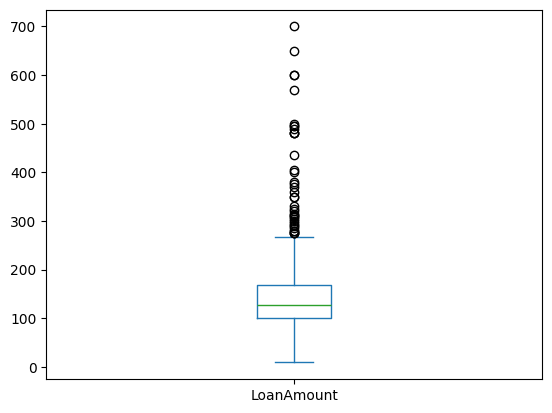

In [12]:
df["LoanAmount"].plot(kind="box")

In [13]:
df["LoanAmount"].fillna(df["LoanAmount"].median())

0      128.0
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
609     71.0
610     40.0
611    253.0
612    187.0
613    133.0
Name: LoanAmount, Length: 614, dtype: float64

In [14]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

In [15]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

In [16]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop("Loan_ID", axis=1, inplace=True)

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])
df = pd.get_dummies(df, columns=["Property_Area"], dtype=int)
df = pd.get_dummies(df, columns=["Dependents"], dtype=int)


In [20]:
df.corr()["Loan_Status"]

Gender                     0.017987
Married                    0.091478
Education                 -0.085884
Self_Employed             -0.003700
ApplicantIncome           -0.004710
CoapplicantIncome         -0.059187
LoanAmount                -0.033214
Loan_Amount_Term          -0.022549
Credit_History             0.540556
Loan_Status                1.000000
Property_Area_Rural       -0.100694
Property_Area_Semiurban    0.136540
Property_Area_Urban       -0.043621
Dependents_0              -0.003044
Dependents_1              -0.038740
Dependents_2               0.062384
Dependents_3+             -0.026123
Name: Loan_Status, dtype: float64

In [21]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score,classification_report
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [30]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("Accuracy score:",accuracy_score(y_test,y_pred))

y_pred1 = model.predict(X_train)
print("Accuracy score:",accuracy_score(y_train,y_pred1))

print("confusion matrix:",confusion_matrix(y_test,y_pred))
print("precision score:",precision_score(y_test,y_pred))
print("Recall score:", recall_score(y_test,y_pred))
print("f1 score:",f1_score(y_test,y_pred))
print("classification report",classification_report(y_test,y_pred))

Accuracy score: 0.7886178861788617
Accuracy score: 0.8187372708757638
confusion matrix: [[18 25]
 [ 1 79]]
precision score: 0.7596153846153846
Recall score: 0.9875
f1 score: 0.8586956521739131
classification report               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

